<a href="https://colab.research.google.com/github/instai4/CODE_ALPHA-TASK1/blob/main/Unemployment_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Plot style
plt.style.use('ggplot')
sns.set(font_scale=1.1)

In [3]:
from google.colab import files
uploaded = files.upload()

Saving Unemployment in India.csv to Unemployment in India (1).csv


In [4]:
import os
print(os.listdir('/content'))

['.config', 'Unemployment in India.csv', 'Unemployment in India (1).csv', 'sample_data']


In [8]:
df = pd.read_csv('/content/Unemployment in India.csv')

In [9]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

In [11]:
import os
os.listdir()

['.config',
 'Unemployment in India.csv',
 'Unemployment in India (1).csv',
 'sample_data']

In [12]:
print(df.shape)

print(df.columns)

df.info()

df.describe()

(768, 7)
Index(['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)',
       ' Estimated Employed', ' Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    object 
 1    Date                                     740 non-null    object 
 2    Frequency                                740 non-null    object 
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    object 
dtypes: float64(3), object(4)
memory usage: 42.1+ KB


,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
count,740.000000,7.400000e+02,740.000000
mean,11.787946,7.204460e+06,42.630122
std,10.721298,8.087988e+06,8.111094
min,0.000000,4.942000e+04,13.330000
25%,4.657500,1.190404e+06,38.062500
50%,8.350000,4.744178e+06,41.160000
75%,15.887500,1.127549e+07,45.505000
max,76.740000,4.577751e+07,72.570000


In [13]:
df.isnull().sum()

,0
Region,28
Date,28
Frequency,28
Estimated Unemployment Rate (%),28
Estimated Employed,28
Estimated Labour Participation Rate (%),28
Area,28


In [14]:
df.columns = df.columns.str.strip()

In [15]:
df['Date'] = pd.to_datetime(df['Date'])

/tmp/ipykernel_1400/2394721818.py:1: UserWarning: Parsing dates in  %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Date'] = pd.to_datetime(df['Date'])


In [16]:
df.duplicated().sum()

np.int64(27)

In [17]:
df = df.drop_duplicates()

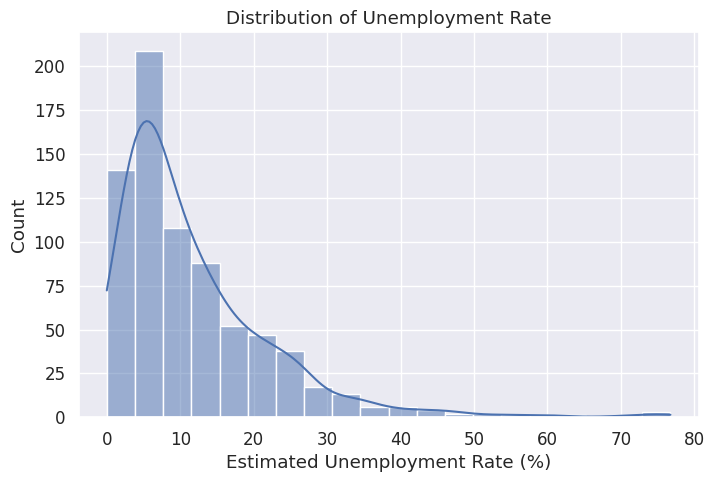

In [18]:
plt.figure(figsize=(8,5))
sns.histplot(df['Estimated Unemployment Rate (%)'], bins=20, kde=True)
plt.title("Distribution of Unemployment Rate")
plt.show()

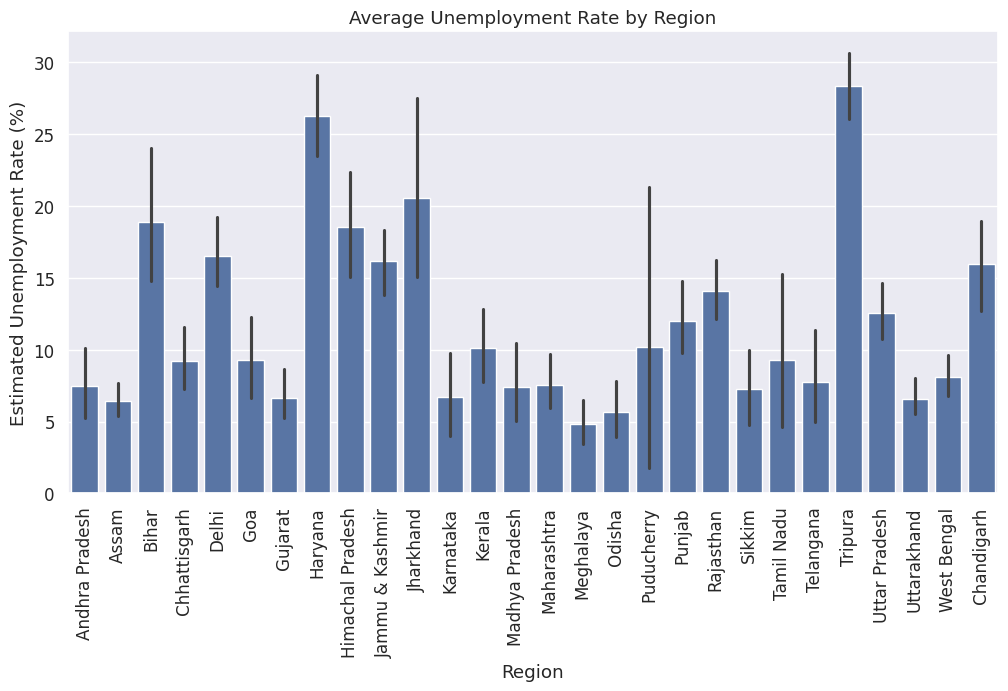

In [19]:
plt.figure(figsize=(12,6))

sns.barplot(
    x='Region',
    y='Estimated Unemployment Rate (%)',
    data=df,
    estimator=np.mean
)

plt.xticks(rotation=90)
plt.title("Average Unemployment Rate by Region")
plt.show()

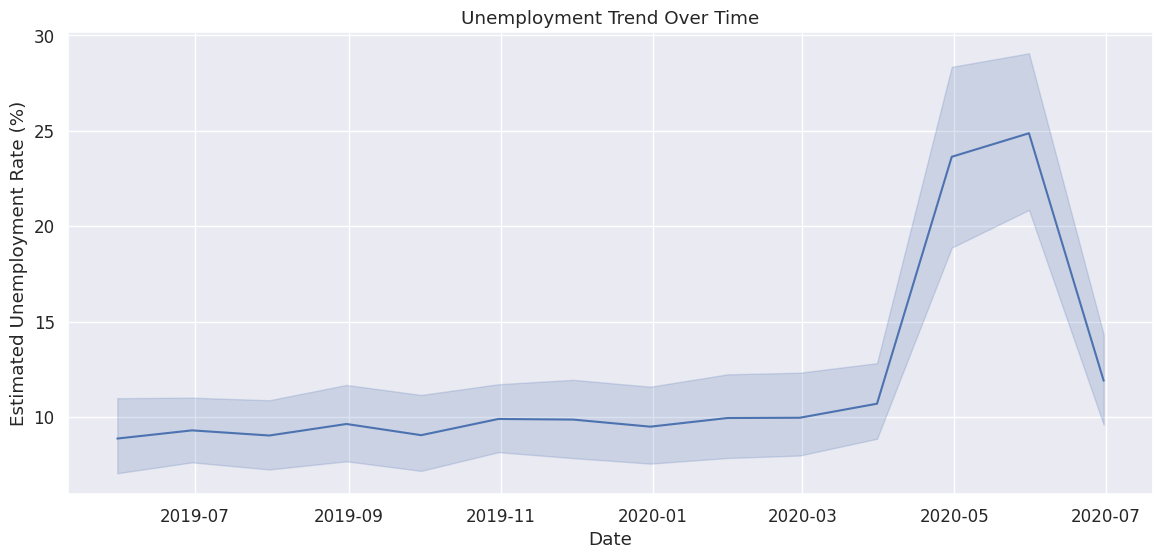

In [20]:
plt.figure(figsize=(14,6))

sns.lineplot(
    x='Date',
    y='Estimated Unemployment Rate (%)',
    data=df
)

plt.title("Unemployment Trend Over Time")
plt.show()

In [21]:
covid = df[df['Date'].dt.year == 2020]

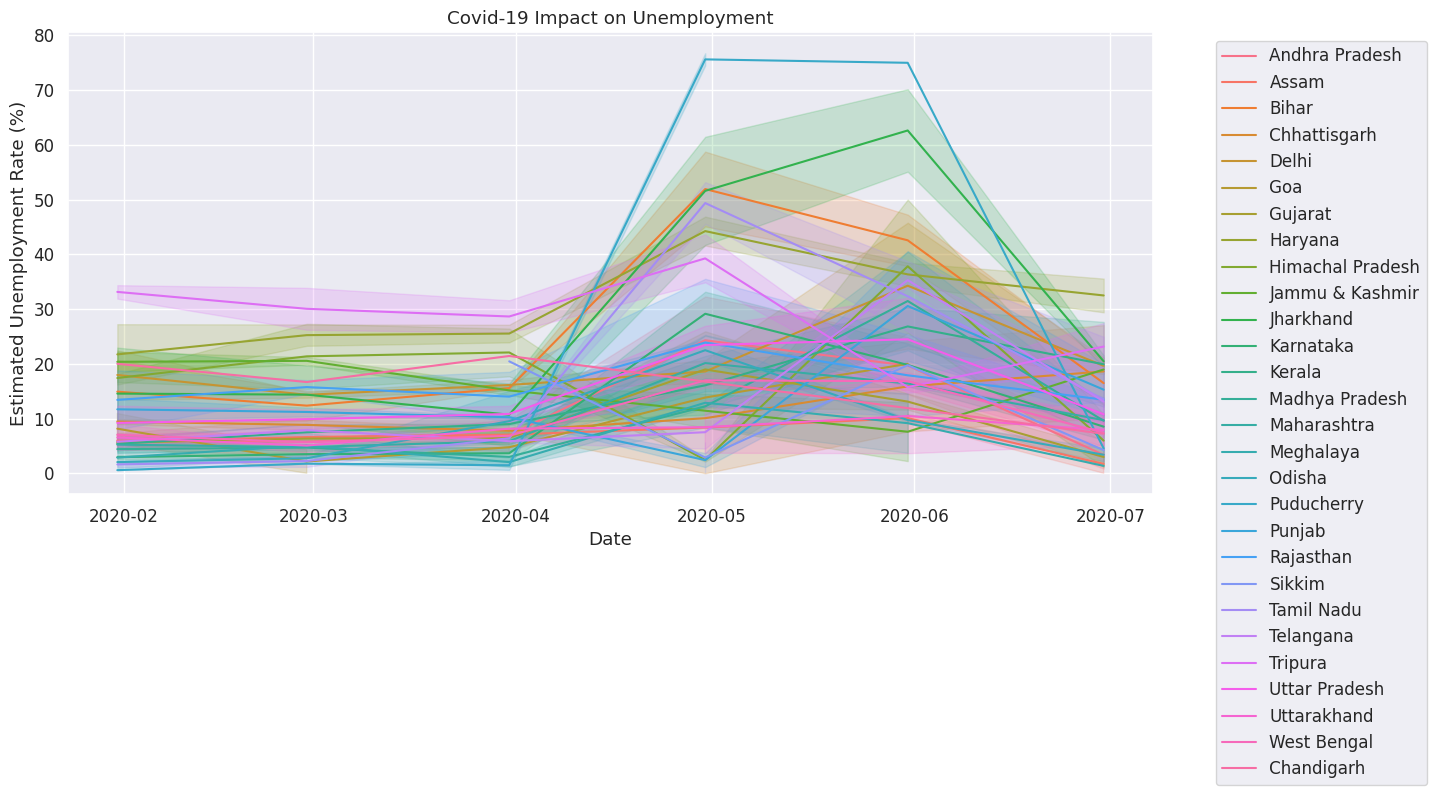

In [22]:
plt.figure(figsize=(14,6))

sns.lineplot(
    x='Date',
    y='Estimated Unemployment Rate (%)',
    data=covid,
    hue='Region'
)

plt.title("Covid-19 Impact on Unemployment")
plt.legend(bbox_to_anchor=(1.05,1))
plt.show()

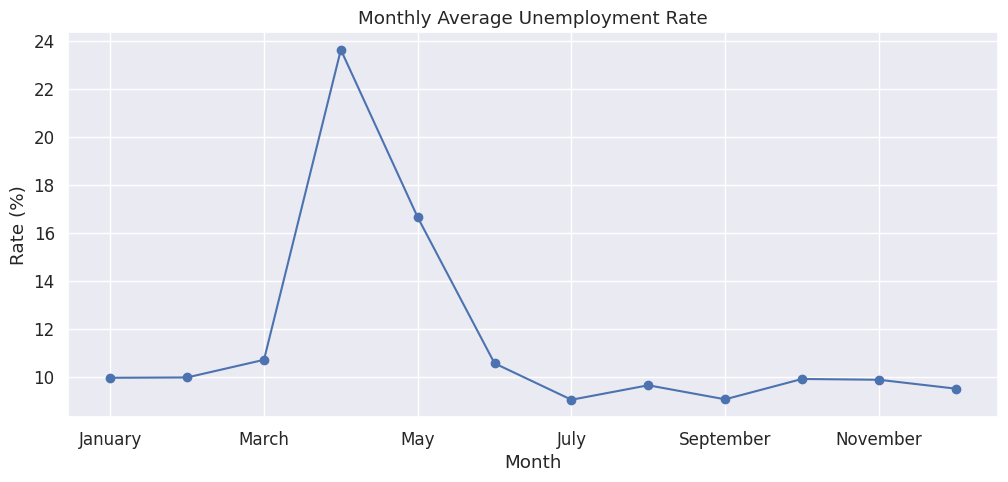

In [23]:
df['Month'] = df['Date'].dt.month_name()

monthly = df.groupby('Month')['Estimated Unemployment Rate (%)'].mean()

monthly = monthly.reindex([
    'January','February','March','April','May','June',
    'July','August','September','October','November','December'
])

plt.figure(figsize=(12,5))

monthly.plot(marker='o')

plt.title("Monthly Average Unemployment Rate")
plt.ylabel("Rate (%)")
plt.show()

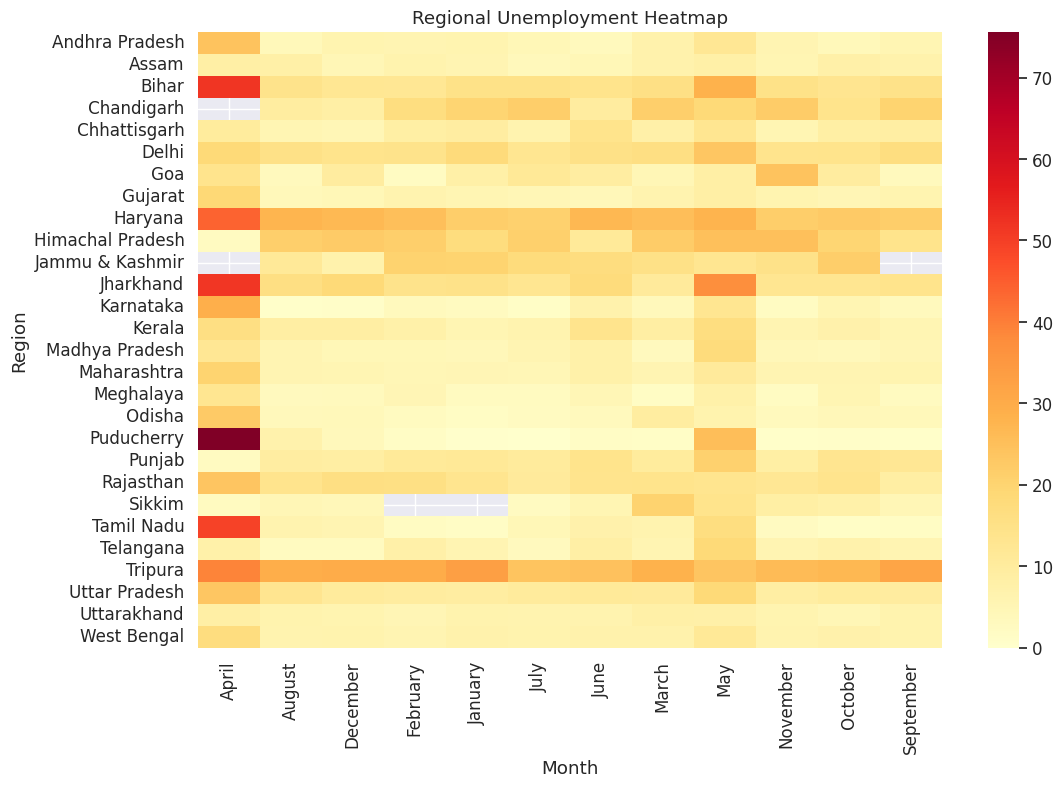

In [24]:
pivot = df.pivot_table(
    values='Estimated Unemployment Rate (%)',
    index='Region',
    columns='Month'
)

plt.figure(figsize=(12,8))

sns.heatmap(pivot, cmap='YlOrRd')

plt.title("Regional Unemployment Heatmap")
plt.show()

In [25]:
highest = df.groupby('Region')['Estimated Unemployment Rate (%)'].mean().sort_values(ascending=False)

print(highest.head())

Region
Tripura             28.350357
Haryana             26.283214
Jharkhand           20.585000
Bihar               18.918214
Himachal Pradesh    18.540357
Name: Estimated Unemployment Rate (%), dtype: float64


In [26]:
print(highest.tail())

Region
Gujarat        6.663929
Uttarakhand    6.582963
Assam          6.428077
Odisha         5.657857
Meghalaya      4.798889
Name: Estimated Unemployment Rate (%), dtype: float64


In [27]:
print("Average Unemployment Rate:", round(df['Estimated Unemployment Rate (%)'].mean(),2))

Average Unemployment Rate: 11.79
